In [1]:
# Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt


## Exercise 1.4

In [2]:
def g(x):
    g = np.exp(-x**2)
    return g

In [3]:
def fd(h):
    g_prime = (g(1+h) - g(1)) / h
    return np.round(g_prime,4)

def bd(h):
    g_prime = (g(1) - g(1-h)) / h
    return np.round(g_prime,4)

def cd(h):
    g_prime = (g(1+h) - g(1-h)) / (2*h)
    return np.round(g_prime,4)

In [4]:
h_array = np.array([0.1, 0.01, 0.001])

In [5]:
for h in h_array:
    # print(fd(h))
    # print(bd(h))
    print(cd(h))

-0.7333
-0.7357
-0.7358


In [6]:
print('actual value is ', -2 / np.e)

actual value is  -0.7357588823428847


## Exercise 1.11
Implement trapezoid rule to estimate the area under the Gaussian curve defined by $g(x) = e^{-x^2}$ ( ```g(x)``` function)

\begin{equation}
    A = \sum_{i=0}^{N-1} \frac{(x_{i+1} - x_i)(g(x_{i+1}) + g(x_i))}{2}
\end{equation}

In [25]:
def trapzx(L, x_length = 200, state=True):
    """
    Parameters:
        L is the distance from 0 that we will use to calculate the integral. for x > L, the integral is approximately 0
        dx is the spacing of x-values (width of trapezoid)
    
    Returns:
        A: Approximate area under the curve calculated using trapezoids (-L,L)
        A_tail: Approximate area under the curve calculated using trapezoids (sum of (-inf, L] U (L, +inf))
        error: Z = pi - A
    """
    # define an x-array
    x = np.linspace(-L,L,x_length)

    # calculate dx 
    dx = np.abs(x[1] - x[0])
    
    # calculate g(x)
    g_array = g(x)
    
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_g = (g_array[:-1] + g_array[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    A = (dx * avg_g).sum()

    # calculate the area under the curve for the tail
    x_tail = np.linspace(L, 10**16, x_length)
    dx = np.abs(x_tail[1] - x_tail[0])
    g_array_tail = g(x_tail)
    avg_g_tail = (g_array_tail[:-1] + g_array_tail[1:]) / 2
    A_tail = (dx * avg_g_tail).sum() * 2 # x2 b/c there are two tails
    

    # compare to the true value of Z = sqrt(pi)
    Z = np.sqrt(np.pi)

    error_minusLtoL = Z - A 
    
    if np.abs(error_minusLtoL < 10**(-16)):
        if state==True:
            print(f'For dx={"%.2e" % dx} and L={L}, the integral of g(x) from -L to L = sqrt(\u03C0)')
        
    return A, A_tail, error_minusLtoL

In [26]:
A, A_tail, error_minusLtoL = trapzx(10,200)

For dx=5.03e+13 and L=10, the integral of g(x) from -L to L = sqrt(π)


### doesn't this also depend on your choice of ``dx``?

## Exercise 1.13a

Write code to calculate the **error function** to calculate the $errf(x)$ for any real $x$ found using the trapezoid function written in Excercise 1.11.

\begin{equation}
    erf(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-t^2} \, \text{d}t
\end{equation}

*I assume there is a time dependence (t) because x can change over time? Like if the Gaussian is advected to the right?*

In [60]:
def erf(x_bound, state=True):
    A, A_tail, error_minusLtoL = trapzx(x_bound, state=False)
    erf = 2/np.sqrt(np.pi) * (A/2) # divide A by 2 since trapzx uses from [-L,L] instead of [0,L] for integral limits
    if state==True:
        print(f'P(error \u2208 (-{x_bound},{x_bound})) =', '%.2e'% erf)
    return erf

In [61]:
erf(0.8)

P(error ∈ (-0.8,0.8)) = 7.42e-01


np.float64(0.7420958363211435)

## Exercise 1.13b
Write code to calculate the inverse error function. Given $erf(x) = y \text{ s.t. } y \in(-1,1)$, what is $x$?

If the error function is the integral of $g(x) = e^{-t^2}$ for limits $x=0, x=L$, then we can take the trapezoid function for increasing values of $x$ until we get an integral equal to the value of $y$?

In [74]:
def inv_erf(y, tol=10**(-1)):
    x_bound = 0
    calculated_erf = 10

    # calculate the area under the g(x) curve for increasing upper bounds of x
    while np.abs(calculated_erf - y) > tol:
        x_bound += 0.1
        calculated_erf = erf(x_bound,False)
        

    print(f'if erf(x)= {y}, then x = {'%.2e' % x_bound}')
       
    return x_bound, calculated_erf, y

In [76]:
inv_erf(0.95)

if erf(x)= 0.95, then x = 1.10e+00


(1.0999999999999999, np.float64(0.8801975301112309), 0.95)

## Exercise 1.15a

Let 
\begin{equation}
    f(x;\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
\end{equation}

be a **normal probability density function**
>- Note that previously, the function g(x) was the non-normalized PDF where $\mu =0,\, \sigma = \frac{1}{\sqrt(2)}, A = 1$.

Evaluate 
\begin{equation}
    P(a; \mu, \sigma) = \int_{\mu - a}^{\mu + a} f(x; \mu, \sigma) \, \text{d}x
\end{equation}

In [119]:
# define f(x; mu, sigma)
def f(x, mu, sigma):
    f = (1/np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x-mu)**2/(2*sigma**2))
    return f

# modify trapezoid function to make bounds [mu-a, mu+a] instead of [-L,L]
def P(a, mu, sigma, x_length = 200):
    # define the limits of integration
    upper_bound = mu + a
    lower_bound = mu - a
    
    # define an x-array
    x = np.linspace(lower_bound,upper_bound,x_length)
    

    # calculate dx 
    dx = np.abs(x[1] - x[0])
    
    # calculate f(x)
    f_array = f(x, mu, sigma)
    
    # calculate the sum of x_{i+1} and x_i for all values of i until i = N-1. Then divide by 2 to get the average g(x) value.
    avg_f = (f_array[:-1] + f_array[1:]) / 2

    # take the sum of the averaged values multiplied by the width of the trapezoid (integrate)
    A = (dx * avg_f).sum()
        
    return A

## Exercise 1.15b & c

Given a fraction $p \in (0,1)$, write a function that uses ``inv_erf`` to find the value of $a$ where
\begin{equation}
    P(a;, \mu, \sigma) = p.
\end{equation}

In [120]:
def inv_P(p, mu, sigma, tol=10**(-1)):
    a_bound = 0
    calculated_P = 10

    # calculate the area under the P(x,mu,sigma) curve for increasing upper bounds of x
    while np.abs(calculated_P - p) > tol:
        a_bound += 0.1
        calculated_P = P(a_bound, mu, sigma)
        

    print(f'if P(x)= {p}, then a = {'%.2e' % a_bound}')
       
    return a_bound, calculated_P, p

### Exercise 1.15d
Test your code (``inv_P``) for $p=0.68$ and $p=0.95$ when $\mu = 0$ and $\sigma = 1$.

In [121]:
inv_P(0.68,0,1)

if P(x)= 0.68, then a = 9.00e-01


(0.8999999999999999, np.float64(0.6318764837874895), 0.68)

In [122]:
inv_P(0.95,0,1)

if P(x)= 0.95, then a = 1.50e+00


(1.5000000000000002, np.float64(0.8663782386729049), 0.95)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pr/xbk_8gxd23x12v_jy009m_sw0000gn/T/ipykernel_9778/3669324.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('$P(x=a; \mu=0, \sigma=1)$')


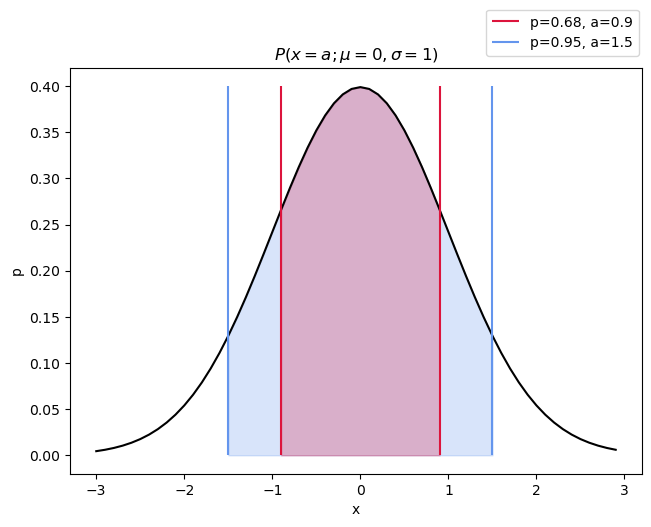

In [170]:
# check work with plot
x_array = np.arange(-3,3,0.1)
p_array = f(x_array, 0, 1)

fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ax.plot(x_array,p_array,color='black')
ax.vlines(-0.9,0,0.4,color='crimson',label='p=0.68, a=0.9')
ax.vlines(0.9,0,0.4,color='crimson')

ax.vlines(-1.5,0,0.4,color='cornflowerblue',label='p=0.95, a=1.5')
ax.vlines(1.5,0,0.4,color='cornflowerblue')

ax.fill_between(x_array[15:46],p_array[15:46],0,alpha=0.25,color='cornflowerblue')
ax.fill_between(x_array[21:40],p_array[21:40],0,alpha=0.25,color='crimson')

ax.set_title('$P(x=a; \mu=0, \sigma=1)$')
ax.set_ylabel('p')
ax.set_xlabel('x')
fig.legend(bbox_to_anchor=(1,1.08))

*Note: Not sure if my search methods match what the packet's MatLab function says to do...* 
In Matlab,
```matlab
    function [x,bracket] = bisectionx(f, bracket, tol, max_iter)
        a = bracket(1);
        b = bracket(2);
        fa = f(a); 
        fb = f(b);
        if (fa * fb > 0)
            fprintf('The interval does not bracket a zero. \n')
            error('f(a) and f(b) have the same sign.')
        else
            i = 0;
            while (abs(b-1) > tol && i < max_iter)
                m=0.5 * (a + b);
                fm = f(m)
                if (fb * fm > 0)
                    b = m;
                    fb = fm;
                else
                    a = m;
                    fa =fm;
                end
                i = i+1;
            end
            x =0.5 * (a + b);
            bracket = [a, b];
        end
    end
```